In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
%matplotlib inline

In [3]:
data = pd.read_csv(r'C:\Users\hlogi\Future_DS_02\ravenstack_subscriptions.csv')

In [4]:
print("Columns:", data.columns)
print("\nFirst 5 rows:\n", data.head())
print("\nData Info:\n", data.info())
print("\nMissing values:\n", data.isnull().sum())

Columns: Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag'],
      dtype='object')

First 5 rows:
   subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5   
4        S-cff5a2   A-ba6516  2024-01-10         NaN  Enterprise     27   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           False       False   
2           0           0   

In [5]:
columns_to_keep = [
    'account_id', 'start_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 
    'churn_flag', 'billing_frequency', 'auto_renew_flag'
]

In [6]:
data = data[columns_to_keep].copy()

In [7]:
data['start_date'] = pd.to_datetime(data['start_date'])

In [8]:
data['churn_flag'] = data['churn_flag'].apply(lambda x: 1 
                                              if x==True 
                                              else 0)

In [9]:
bool_cols = ['is_trial', 'upgrade_flag', 'downgrade_flag', 'auto_renew_flag']
for col in bool_cols:
    data[col] = data[col].astype(int)

In [10]:
data['cohort_month'] = data['start_date'].dt.to_period('M')

In [11]:
print("Columns after cleaning:\n", data.columns)
print("\nFirst 5 rows:\n", data.head())

Columns after cleaning:
 Index(['account_id', 'start_date', 'plan_tier', 'seats', 'mrr_amount',
       'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag',
       'churn_flag', 'billing_frequency', 'auto_renew_flag', 'cohort_month'],
      dtype='object')

First 5 rows:
   account_id start_date   plan_tier  seats  mrr_amount  arr_amount  is_trial  \
0   A-3c1a3f 2023-12-23  Enterprise     14        2786       33432         0   
1   A-9b9fe9 2024-06-11         Pro     17         833        9996         0   
2   A-659280 2024-11-25  Enterprise     62           0           0         1   
3   A-e7a1e2 2024-11-23  Enterprise      5         995       11940         0   
4   A-ba6516 2024-01-10  Enterprise     27        5373       64476         0   

   upgrade_flag  downgrade_flag  churn_flag billing_frequency  \
0             0               0           1           monthly   
1             0               0           0           monthly   
2             1               0           0  

In [12]:
data.to_csv('cleaned_ravenstack_subscriptions.csv', index=False)
print("\nCleaned data saved as 'cleaned_ravenstack_subscriptions.csv'")


Cleaned data saved as 'cleaned_ravenstack_subscriptions.csv'


In [13]:
overall_churn = data['churn_flag'].mean()
print(f"Overall Churn Rate: {overall_churn*100:2f}%")

Overall Churn Rate: 9.720000%


In [14]:
churn_by_plan = data.groupby('plan_tier')['churn_flag'].mean().sort_values(ascending=False)
print("\nChurn Rate by Plan Tier:\n", churn_by_plan)


Churn Rate by Plan Tier:
 plan_tier
Enterprise    0.099826
Pro           0.096716
Basic         0.094881
Name: churn_flag, dtype: float64


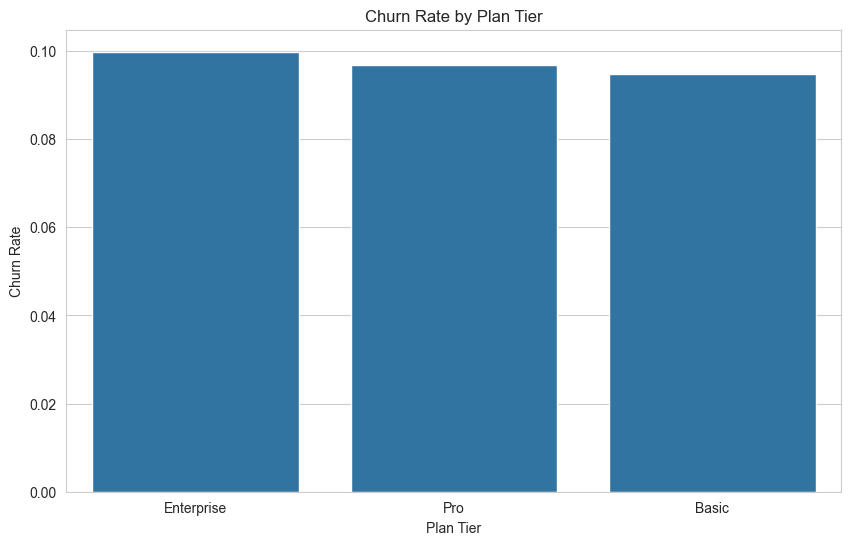

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x=churn_by_plan.index, y=churn_by_plan.values)
plt.title('Churn Rate by Plan Tier')
plt.ylabel('Churn Rate')
plt.xlabel('Plan Tier')
plt.show()

In [16]:
churn_by_billing = data.groupby('billing_frequency')['churn_flag'].mean().sort_values(ascending=False)
print("\nChurn Rate by Billing Frequency:\n", churn_by_billing)


Churn Rate by Billing Frequency:
 billing_frequency
annual     0.100366
monthly    0.094132
Name: churn_flag, dtype: float64


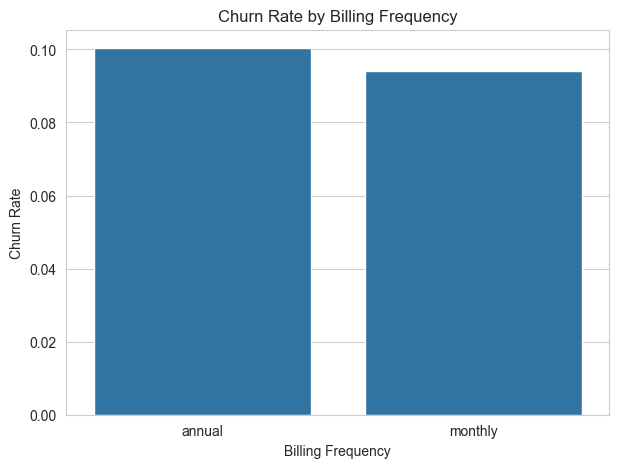

In [17]:
plt.figure(figsize=(7,5))
sns.barplot(x=churn_by_billing.index, y=churn_by_billing.values)
plt.title("Churn Rate by Billing Frequency")
plt.ylabel("Churn Rate")
plt.xlabel("Billing Frequency")
plt.show()

In [18]:
churn_by_auto = data.groupby('auto_renew_flag')['churn_flag'].mean().sort_values(ascending=False)
print("\nChurn Rate by Auto-Renew:\n", churn_by_auto)


Churn Rate by Auto-Renew:
 auto_renew_flag
1    0.097378
0    0.096482
Name: churn_flag, dtype: float64


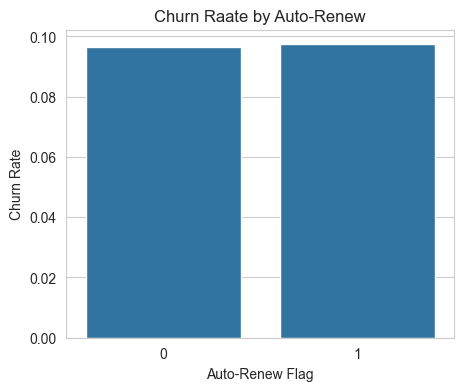

In [19]:
plt.figure(figsize=(5,4))
sns.barplot(x=churn_by_auto.index, y=churn_by_auto.values)
plt.title("Churn Raate by Auto-Renew")
plt.ylabel("Churn Rate")
plt.xlabel("Auto-Renew Flag")
plt.show()

In [20]:
churn_by_trial = data.groupby('is_trial')['churn_flag'].mean().sort_values(ascending=False)
print("\nChurn Rate by Trial vs Paid Users:\n", churn_by_trial)


Churn Rate by Trial vs Paid Users:
 is_trial
1    0.100257
0    0.096637
Name: churn_flag, dtype: float64


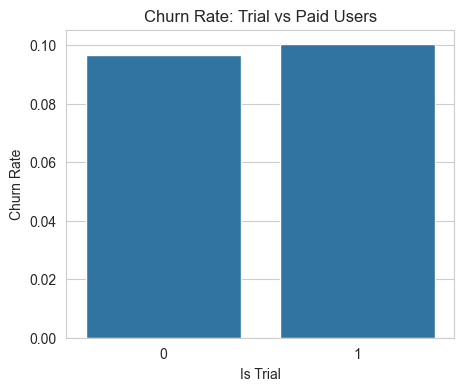

In [21]:
plt.figure(figsize=(5,4))
sns.barplot(x=churn_by_trial.index, y=churn_by_trial.values)
plt.title("Churn Rate: Trial vs Paid Users")
plt.ylabel("Churn Rate")
plt.xlabel("Is Trial")
plt.show()

In [22]:
avg_metrics = data.groupby('churn_flag')[['seats', 'mrr_amount', 'arr_amount']].mean()
avg_metrics.index = ['Active', 'Churned']
print("\nAverage Seats & Revenue by Churn Status:\n", avg_metrics)


Average Seats & Revenue by Churn Status:
              seats   mrr_amount    arr_amount
Active   29.853345  2250.688525  27008.262295
Churned  29.839506  2426.211934  29114.543210


In [23]:
data = pd.read_csv('cleaned_ravenstack_subscriptions.csv')
data['start_date'] = pd.to_datetime(data['start_date'])

In [24]:
today = pd.to_datetime('2026-04-16')

In [25]:
data['tenure_months'] = ((today - data['start_date']).dt.days / 30).apply(np.floor)

In [26]:
data['cohort_month'] = data['start_date'].dt.to_period('M')

In [27]:
data_filtered = data[data['tenure_months'] > 0]

In [29]:
# Sort by account and start date
data = data.sort_values(['account_id', 'start_date'])

# Create cohort_index = number of months since the customer's first subscription
data['first_order_month'] = data.groupby('account_id')['start_date'].transform('min').dt.to_period('M')
data['cohort_index'] = (data['cohort_month'] - data['first_order_month']).apply(lambda x: x.n)

print("cohort_index created successfully!")
print(data[['account_id', 'cohort_month', 'first_order_month', 'cohort_index']].head(10))

cohort_index created successfully!
     account_id cohort_month first_order_month  cohort_index
1940   A-00bed1      2023-11           2023-11             0
4411   A-00bed1      2024-04           2023-11             5
3774   A-00bed1      2024-05           2023-11             6
2855   A-00bed1      2024-05           2023-11             6
109    A-00bed1      2024-07           2023-11             8
3193   A-00bed1      2024-07           2023-11             8
3857   A-00bed1      2024-08           2023-11             9
678    A-00bed1      2024-08           2023-11             9
658    A-00bed1      2024-08           2023-11             9
3126   A-00bed1      2024-09           2023-11            10


In [30]:
cohort_counts = data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='account_id',
    aggfunc='nunique'
)

In [31]:
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

In [32]:
retention.reset_index().to_csv('raven_cohort_retention.csv', index=False)
print("\nCohort retention data saved as 'raven_cohort_retention.csv'")


Cohort retention data saved as 'raven_cohort_retention.csv'


In [33]:
retention_filled = retention.fillna(0)

retention_filled.reset_index().to_csv('raven_cohort_retention_clean_fixed.csv', index=False)
print("Cleaned retention CSV saved as raven_cohort_retention_clean_fixed.csv")

Cleaned retention CSV saved as raven_cohort_retention_clean_fixed.csv


In [35]:
print("Shape:", data.shape)
print("\nColumns:",  data.columns.tolist())
print("\nTenure months sample:", data['churn_flag'].value_counts())
print("\nTenure months sample:", data['tenure_months'].describe())
print("\nCohort month sample:", data['cohort_month'].head())

Shape: (5000, 16)

Columns: ['account_id', 'start_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag', 'cohort_month', 'tenure_months', 'first_order_month', 'cohort_index']

Tenure months sample: churn_flag
0    4514
1     486
Name: count, dtype: int64

Tenure months sample: count    5000.000000
mean       20.875000
std         5.187134
min        15.000000
25%        17.000000
50%        19.000000
75%        24.000000
max        39.000000
Name: tenure_months, dtype: float64

Cohort month sample: 1940    2023-11
4411    2024-04
3774    2024-05
2855    2024-05
109     2024-07
Name: cohort_month, dtype: period[M]


In [36]:
# Monthly churn trend
monthly_churn = data.groupby('cohort_month')['churn_flag'].agg(['sum', 'count']).reset_index()
monthly_churn.columns = ['cohort_month', 'churned', 'total']
monthly_churn['churn_rate'] = (monthly_churn['churned'] / monthly_churn['total']).round(4)
monthly_churn['cohort_month'] = monthly_churn['cohort_month'].astype(str)

monthly_churn.to_csv('monthly_churn_trend.csv', index=False)
print("✅ Saved as 'monthly_churn_trend.csv'")
print(monthly_churn)

✅ Saved as 'monthly_churn_trend.csv'
   cohort_month  churned  total  churn_rate
0       2023-01        0      3      0.0000
1       2023-02        4     11      0.3636
2       2023-03        2     17      0.1176
3       2023-04        2     31      0.0645
4       2023-05        5     29      0.1724
5       2023-06        4     46      0.0870
6       2023-07       10     59      0.1695
7       2023-08        8     82      0.0976
8       2023-09       14     62      0.2258
9       2023-10        9     84      0.1071
10      2023-11       16    121      0.1322
11      2023-12       11    121      0.0909
12      2024-01       14    134      0.1045
13      2024-02       19    152      0.1250
14      2024-03       11    186      0.0591
15      2024-04       19    193      0.0984
16      2024-05       21    245      0.0857
17      2024-06       19    248      0.0766
18      2024-07       21    330      0.0636
19      2024-08       26    337      0.0772
20      2024-09       43    440      0.

In [37]:
# Tenure bucket segmentation
bins = [0, 3, 6, 12, 24, float('inf')]
labels = ['0-3 months', '3-6 months', '6-12 months', '12-24 months', '24+ months']
data['tenure_bucket'] = pd.cut(data['tenure_months'], bins=bins, labels=labels)

tenure_churn = data.groupby('tenure_bucket', observed=True)['churn_flag'].agg(['sum', 'count']).reset_index()
tenure_churn.columns = ['tenure_bucket', 'churned', 'total']
tenure_churn['churn_rate'] = (tenure_churn['churned'] / tenure_churn['total']).round(4)
tenure_churn['retention_rate'] = (1 - tenure_churn['churn_rate']).round(4)

tenure_churn.to_csv('tenure_churn.csv', index=False)
print("✅ Saved as 'tenure_churn.csv'")
print(tenure_churn)

✅ Saved as 'tenure_churn.csv'
  tenure_bucket  churned  total  churn_rate  retention_rate
0  12-24 months      357   3885      0.0919          0.9081
1    24+ months      129   1115      0.1157          0.8843


In [38]:
# Adjusted tenure buckets to match your data range (15-39 months)
bins = [0, 18, 24, 30, 36, float('inf')]
labels = ['Under 18 months', '18-24 months', '24-30 months', '30-36 months', '36+ months']
data['tenure_bucket'] = pd.cut(data['tenure_months'], bins=bins, labels=labels)

tenure_churn = data.groupby('tenure_bucket', observed=True)['churn_flag'].agg(['sum', 'count']).reset_index()
tenure_churn.columns = ['tenure_bucket', 'churned', 'total']
tenure_churn['churn_rate'] = (tenure_churn['churned'] / tenure_churn['total']).round(4)
tenure_churn['retention_rate'] = (1 - tenure_churn['churn_rate']).round(4)

tenure_churn.to_csv('tenure_churn.csv', index=False)
print("✅ Saved as 'tenure_churn.csv'")
print(tenure_churn)

✅ Saved as 'tenure_churn.csv'
     tenure_bucket  churned  total  churn_rate  retention_rate
0  Under 18 months      221   2175      0.1016          0.8984
1     18-24 months      136   1710      0.0795          0.9205
2     24-30 months       80    778      0.1028          0.8972
3     30-36 months       42    304      0.1382          0.8618
4       36+ months        7     33      0.2121          0.7879


In [39]:
# Revenue at risk from churned customers
revenue_at_risk = data[data['churn_flag'] == 1].groupby('plan_tier').agg(
    churned_customers=('account_id', 'nunique'),
    total_mrr_at_risk=('mrr_amount', 'sum'),
    avg_mrr_at_risk=('mrr_amount', 'mean')
).reset_index()

revenue_at_risk['total_mrr_at_risk'] = revenue_at_risk['total_mrr_at_risk'].round(2)
revenue_at_risk['avg_mrr_at_risk'] = revenue_at_risk['avg_mrr_at_risk'].round(2)

revenue_at_risk.to_csv('revenue_at_risk.csv', index=False)
print("✅ Saved as 'revenue_at_risk.csv'")
print(revenue_at_risk)

✅ Saved as 'revenue_at_risk.csv'
    plan_tier  churned_customers  total_mrr_at_risk  avg_mrr_at_risk
0       Basic                132              72523           477.12
1  Enterprise                146             926345          5385.73
2         Pro                141             180271          1112.78


In [40]:
import os

# Final summary by plan tier
summary = data.groupby('plan_tier').agg(
    total_customers=('account_id', 'nunique'),
    churned=('churn_flag', 'sum'),
    total_mrr=('mrr_amount', 'sum'),
    avg_mrr=('mrr_amount', 'mean'),
    avg_seats=('seats', 'mean')
).reset_index()

summary['churn_rate'] = (summary['churned'] / summary['total_customers']).round(4)
summary['retention_rate'] = (1 - summary['churn_rate']).round(4)
summary['avg_mrr'] = summary['avg_mrr'].round(2)
summary['avg_seats'] = summary['avg_seats'].round(1)

summary.to_csv('plan_summary.csv', index=False)
print("✅ Saved as 'plan_summary.csv'")
print(summary)

# Confirm all files are ready
print("\n📁 Files ready for Power BI:")
files = [
    'cleaned_ravenstack_subscriptions.csv',
    'monthly_churn_trend.csv',
    'tenure_churn.csv',
    'revenue_at_risk.csv',
    'raven_cohort_retention.csv',
    'plan_summary.csv'
]
for f in files:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"  {status} {f}")

✅ Saved as 'plan_summary.csv'
    plan_tier  total_customers  churned  total_mrr  avg_mrr  avg_seats  \
0       Basic              480      152     760437   474.68       29.6   
1  Enterprise              479      172    8473221  4917.71       29.4   
2         Pro              474      162    2105089  1256.77       30.6   

   churn_rate  retention_rate  
0      0.3167          0.6833  
1      0.3591          0.6409  
2      0.3418          0.6582  

📁 Files ready for Power BI:
  ✅ cleaned_ravenstack_subscriptions.csv
  ✅ monthly_churn_trend.csv
  ✅ tenure_churn.csv
  ✅ revenue_at_risk.csv
  ✅ raven_cohort_retention.csv
  ✅ plan_summary.csv


In [41]:
# Check what the cohort retention CSV actually looks like
cohort_check = pd.read_csv('raven_cohort_retention.csv')
print(cohort_check.head(3))
print("\nColumns:", cohort_check.columns.tolist())
print("Shape:", cohort_check.shape)

  cohort_month    0         1         2   3   4   5   6   7   8  ...  13  14  \
0      2023-01  1.0       NaN       NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN   
1      2023-02  1.0  0.125000       NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN   
2      2023-03  1.0  0.363636  0.090909 NaN NaN NaN NaN NaN NaN  ... NaN NaN   

   15  16  17  18  19  20  21  22  
0 NaN NaN NaN NaN NaN NaN NaN NaN  
1 NaN NaN NaN NaN NaN NaN NaN NaN  
2 NaN NaN NaN NaN NaN NaN NaN NaN  

[3 rows x 24 columns]

Columns: ['cohort_month', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22']
Shape: (24, 24)


In [42]:
print(monthly_churn['churn_rate'].unique())
print(monthly_churn['churn_rate'].dtype)

[0.     0.3636 0.1176 0.0645 0.1724 0.087  0.1695 0.0976 0.2258 0.1071
 0.1322 0.0909 0.1045 0.125  0.0591 0.0984 0.0857 0.0766 0.0636 0.0772
 0.0977 0.0833 0.1029 0.1081]
float64


In [43]:
# Re-export monthly_churn_trend with explicit decimal formatting
monthly_churn['churn_rate'] = monthly_churn['churn_rate'].astype(float)
monthly_churn['churned'] = monthly_churn['churned'].astype(int)
monthly_churn['total'] = monthly_churn['total'].astype(int)
monthly_churn.to_csv('monthly_churn_trend.csv', index=False, float_format='%.4f')
print("✅ Re-exported successfully")
print(monthly_churn.dtypes)

✅ Re-exported successfully
cohort_month     object
churned           int32
total             int32
churn_rate      float64
dtype: object


In [44]:
# Reload and fix cohort retention
cohort_check = pd.read_csv('raven_cohort_retention.csv')
print(cohort_check.head(3))

# Round all values to 2 decimal places
cohort_cols = [col for col in cohort_check.columns if col != 'cohort_month']
cohort_check[cohort_cols] = cohort_check[cohort_cols].round(2)
cohort_check.to_csv('raven_cohort_retention_fixed.csv', index=False)
print("✅ Saved!")

  cohort_month    0         1         2   3   4   5   6   7   8  ...  13  14  \
0      2023-01  1.0       NaN       NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN   
1      2023-02  1.0  0.125000       NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN   
2      2023-03  1.0  0.363636  0.090909 NaN NaN NaN NaN NaN NaN  ... NaN NaN   

   15  16  17  18  19  20  21  22  
0 NaN NaN NaN NaN NaN NaN NaN NaN  
1 NaN NaN NaN NaN NaN NaN NaN NaN  
2 NaN NaN NaN NaN NaN NaN NaN NaN  

[3 rows x 24 columns]
✅ Saved!


In [45]:
# Reload original cohort data and rebuild properly
data = pd.read_csv('cleaned_ravenstack_subscriptions.csv')
data['start_date'] = pd.to_datetime(data['start_date'])
data['cohort_month'] = data['start_date'].dt.to_period('M')

# Rebuild cohort_index
data = data.sort_values(['account_id', 'start_date'])
data['first_order_month'] = data.groupby('account_id')['start_date'].transform('min').dt.to_period('M')
data['cohort_index'] = (data['cohort_month'] - data['first_order_month']).apply(lambda x: x.n)

# Only keep 0-12
data_filtered = data[data['cohort_index'] <= 12]

# Build cohort table
cohort_counts = data_filtered.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='account_id',
    aggfunc='nunique'
)

cohort_sizes = cohort_counts[0]
retention = cohort_counts.divide(cohort_sizes, axis=0).round(2)

# Rename columns to M+0, M+1 etc
retention.columns = [f'M+{i}' for i in retention.columns]
retention.index = retention.index.astype(str)
retention = retention.reset_index()
retention.columns.name = None

# Fill NaN with empty
retention = retention.fillna('')

retention.to_csv('raven_cohort_retention_fixed.csv', index=False)
print("✅ Saved!")
print(retention.head(3))
print("Columns:", retention.columns.tolist())

✅ Saved!
  cohort_month  M+0   M+1   M+2 M+3 M+4 M+5 M+6 M+7 M+8 M+9 M+10 M+11 M+12
0      2023-01  1.0                                                       
1      2023-02  1.0  0.12                                                 
2      2023-03  1.0  0.36  0.09                                           
Columns: ['cohort_month', 'M+0', 'M+1', 'M+2', 'M+3', 'M+4', 'M+5', 'M+6', 'M+7', 'M+8', 'M+9', 'M+10', 'M+11', 'M+12']
